In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    recall_score,
    accuracy_score,
    precision_score,
    roc_auc_score,
    average_precision_score,
    make_scorer,
    classification_report, 
    precision_recall_curve,
    auc
)
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.base import clone
import shap
import tqdm

c:\Users\mb_pe\AppData\Local\pypoetry\Cache\virtualenvs\projet-4-H8xYhlhN-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Chargement des données

In [3]:
df_eval = pd.read_csv('../data/raw/extrait_eval.csv')
df_sirh = pd.read_csv('../data/raw/extrait_sirh.csv')
df_sondage = pd.read_csv('../data/raw/extrait_sondage.csv')

# EDA & Data preparation

### 1) Analyse descriptive

In [57]:
def describe_df(df, name="df"):
    print("\n")
    print("="*60)
    print(f"{name} : shape = {df.shape}")
    print("="*60)

    print("\n----- Data types: -----")
    display(df.dtypes)
    print("\n----- Missing values (count / %): -----")
    miss = df.isna().sum()
    print(pd.concat([miss, 100*miss/len(df)], axis=1).rename(columns={0:"missing_count", 1:"missing_pct"}))

    print("\n----- Duplicated rows:", df.duplicated().sum(), "-----")

    print("\n----- Unique values : -----")
    print(df.nunique().sort_values(ascending=False))
    
    print("\n----- Numerical columns analysis : -----")
    # Numeric
    num_with_id = df.select_dtypes(include='number') 
    num = num_with_id.drop(columns=['eval_number', 'id_employee', 'code_sondage'], errors='ignore')
    if not num.empty:
        # on calcul les stats (avec skew & kurtosis) des colonnes numériques - hors id
        desc = num.describe().T
        desc['skew'] = num.skew()
        desc['kurtosis'] = num.kurtosis()
        # on affiche les stats
        display(desc)


describe_df(df_eval, 'df_eval')
describe_df(df_sirh, 'df_sirh')
describe_df(df_sondage, 'df_sondage')



df_eval : shape = (1470, 10)

----- Data types: -----


satisfaction_employee_environnement          int64
note_evaluation_precedente                   int64
niveau_hierarchique_poste                    int64
satisfaction_employee_nature_travail         int64
satisfaction_employee_equipe                 int64
satisfaction_employee_equilibre_pro_perso    int64
eval_number                                    str
note_evaluation_actuelle                     int64
heure_supplementaires                          str
augementation_salaire_precedente               str
dtype: object


----- Missing values (count / %): -----
                                           missing_count  missing_pct
satisfaction_employee_environnement                    0          0.0
note_evaluation_precedente                             0          0.0
niveau_hierarchique_poste                              0          0.0
satisfaction_employee_nature_travail                   0          0.0
satisfaction_employee_equipe                           0          0.0
satisfaction_employee_equilibre_pro_perso              0          0.0
eval_number                                            0          0.0
note_evaluation_actuelle                               0          0.0
heure_supplementaires                                  0          0.0
augementation_salaire_precedente                       0          0.0

----- Duplicated rows: 0 -----

----- Unique values : -----
eval_number                                  1470
augementation_salaire_precedente               15
niveau_hierarchique_poste   

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
satisfaction_employee_environnement,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.0,4.0,-0.321654,-1.202521
note_evaluation_precedente,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.0,4.0,-0.498419,0.270999
niveau_hierarchique_poste,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.0,5.0,1.025401,0.399152
satisfaction_employee_nature_travail,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.0,4.0,-0.329672,-1.222193
satisfaction_employee_equipe,1470.0,2.712245,1.081209,1.0,2.0,3.0,4.0,4.0,-0.302828,-1.184814
satisfaction_employee_equilibre_pro_perso,1470.0,2.761224,0.706476,1.0,2.0,3.0,3.0,4.0,-0.552480,0.419460
note_evaluation_actuelle,1470.0,3.153741,0.360824,3.0,3.0,3.0,3.0,4.0,1.921883,1.695939




df_sirh : shape = (1470, 12)

----- Data types: -----


...

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.0,60.0,0.413286,-0.404145
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0,1.369817,1.005233
nombre_experiences_precedentes,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0,1.026471,0.010214
nombre_heures_travailless,1470.0,80.000000,0.000000,80.0,80.0,80.0,80.0,80.0,0.000000,0.000000
annee_experience_totale,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0,1.117172,0.918270
annees_dans_l_entreprise,1470.0,7.008163,6.126525,0.0,3.0,5.0,9.0,40.0,1.764529,3.935509
annees_dans_le_poste_actuel,1470.0,4.229252,3.623137,0.0,2.0,3.0,7.0,18.0,0.917363,0.477421




df_sondage : shape = (1470, 12)

----- Data types: -----


a_quitte_l_entreprise                    str
nombre_participation_pee               int64
nb_formations_suivies                  int64
nombre_employee_sous_responsabilite    int64
code_sondage                           int64
distance_domicile_travail              int64
niveau_education                       int64
domaine_etude                            str
ayant_enfants                            str
frequence_deplacement                    str
annees_depuis_la_derniere_promotion    int64
annes_sous_responsable_actuel          int64
dtype: object


----- Missing values (count / %): -----
                                     missing_count  missing_pct
a_quitte_l_entreprise                            0          0.0
nombre_participation_pee                         0          0.0
nb_formations_suivies                            0          0.0
nombre_employee_sous_responsabilite              0          0.0
code_sondage                                     0          0.0
distance_domicile_travail                        0          0.0
niveau_education                                 0          0.0
domaine_etude                                    0          0.0
ayant_enfants                                    0          0.0
frequence_deplacement                            0          0.0
annees_depuis_la_derniere_promotion              0          0.0
annes_sous_responsable_actuel                    0          0.0

----- Duplicated rows: 0 -----

----- Unique values : -----
code_sondage                           1470
distance_domicile_trav

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
nombre_participation_pee,1470.0,0.793878,0.852077,0.0,0.0,1.0,1.0,3.0,0.968980,0.364634
nb_formations_suivies,1470.0,2.799320,1.289271,0.0,2.0,3.0,3.0,6.0,0.553124,0.494993
nombre_employee_sous_responsabilite,1470.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0,0.000000,0.000000
distance_domicile_travail,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0,0.958118,-0.224833
niveau_education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0,-0.289681,-0.559115
annees_depuis_la_derniere_promotion,1470.0,2.187755,3.222430,0.0,0.0,1.0,3.0,15.0,1.984290,3.612673
annes_sous_responsable_actuel,1470.0,4.123129,3.568136,0.0,2.0,3.0,7.0,17.0,0.833451,0.171058


L'analyse descriptive indique la présence d'aucune valeur NULL. On observe 3 colonnes constantes : nombre_heures_travailless, nombre_employee_sous_responsabilite et ayant_enfants

### 2) Transformation des colonnes

In [4]:
# On se débarasse des '%' pour avoir la colonne en float au lieu de string
df_eval['augementation_salaire_precedente'] = (
    df_eval['augementation_salaire_precedente']
    .str.replace('%', '', regex=False)
    .str.strip()
    .astype(float)
)

In [5]:
# Garder uniquement la partie après '_' dans 'eval_number' et convertir la colonne en Int64
# On conserve une copie brute 'eval_number_raw' pour vérification
print(df_eval["eval_number"].dtype)
df_eval['eval_number_raw'] = df_eval['eval_number'].astype(str)
df_eval['eval_number'] = df_eval['eval_number_raw'].str.rsplit('_', n=1).str[-1]
df_eval['eval_number'] = pd.to_numeric(df_eval['eval_number'], errors='coerce').astype('Int64')
print(df_eval["eval_number"].dtype)

object
Int64


### 3) Suppression des colonnes inutiles (constantes)

In [6]:
# on supprime les colonnes inutiles
df_eval.drop(columns=["eval_number_raw"], inplace=True)
df_sirh.drop(columns=["nombre_heures_travailless"], inplace=True)
df_sondage.drop(columns=["nombre_employee_sous_responsabilite", "ayant_enfants"], inplace=True)

### 4) Jointure des dataframes

In [7]:
df = df_sirh.merge(df_eval, left_on="id_employee", right_on="eval_number", how="left")
df = df.merge(df_sondage, left_on="id_employee", right_on="code_sondage", how="left")
df = df.drop(columns=["eval_number", "code_sondage"])
print(df.shape)

(1470, 29)


In [8]:
with pd.option_context('display.max_columns', None):
    display(df.head(2))

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,8,6,4,2,3,2,4,1,1,3,Oui,11.0,Oui,0,0,1,2,Infra & Cloud,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,10,10,7,3,2,2,2,4,3,4,Non,23.0,Non,1,3,8,1,Infra & Cloud,Frequent,1,7


### 5) Afficher la distributions des colonnes : différences clés entre les employés

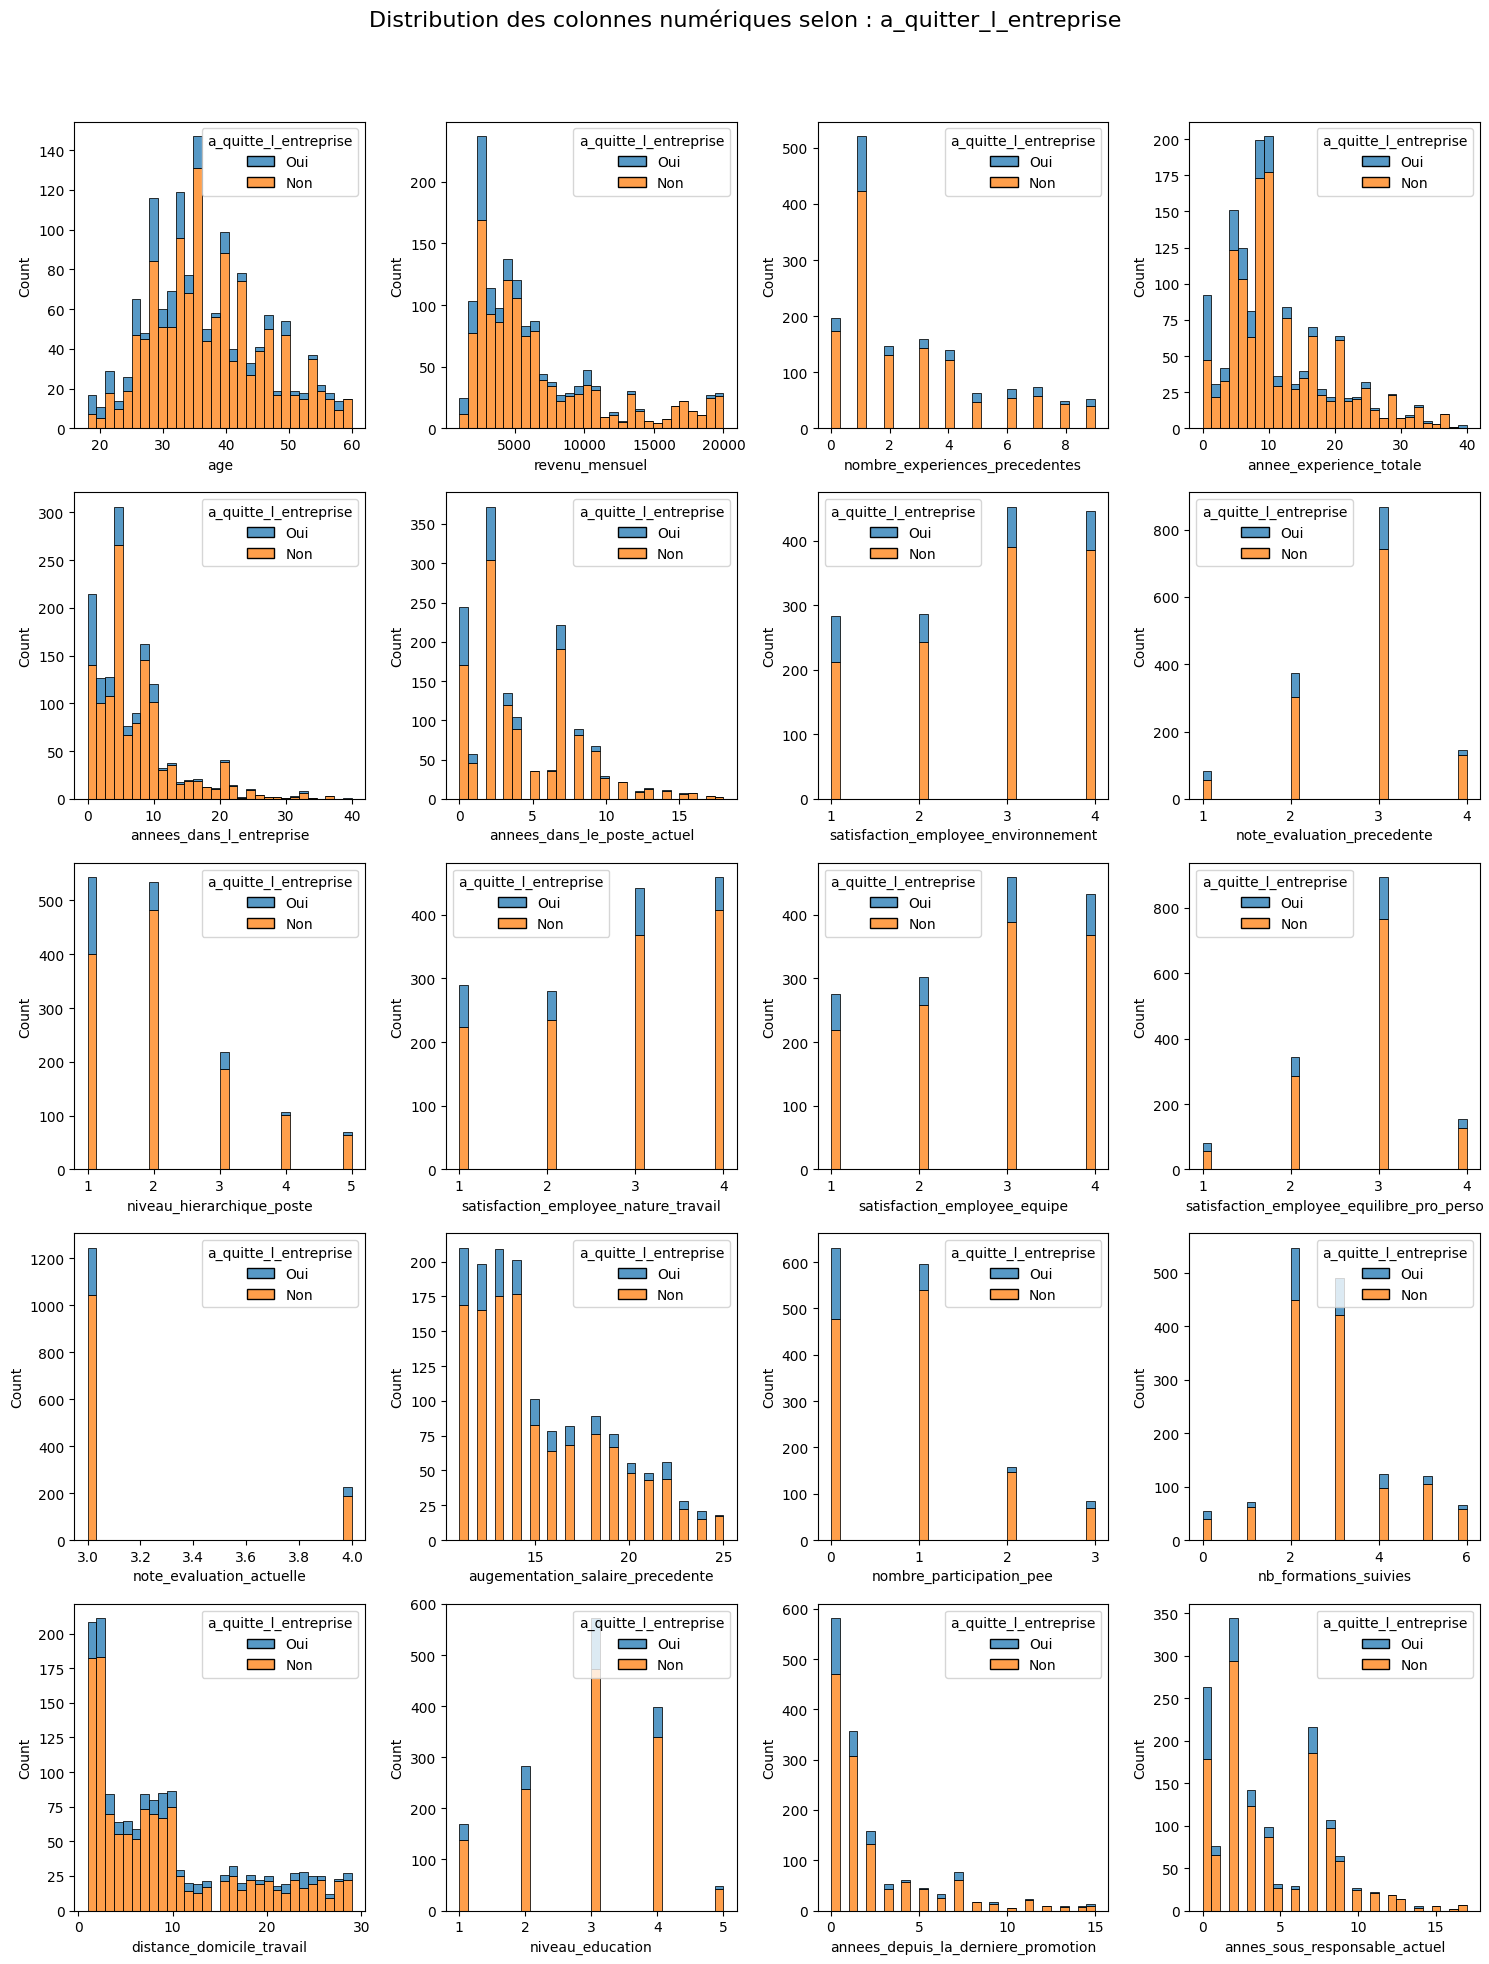

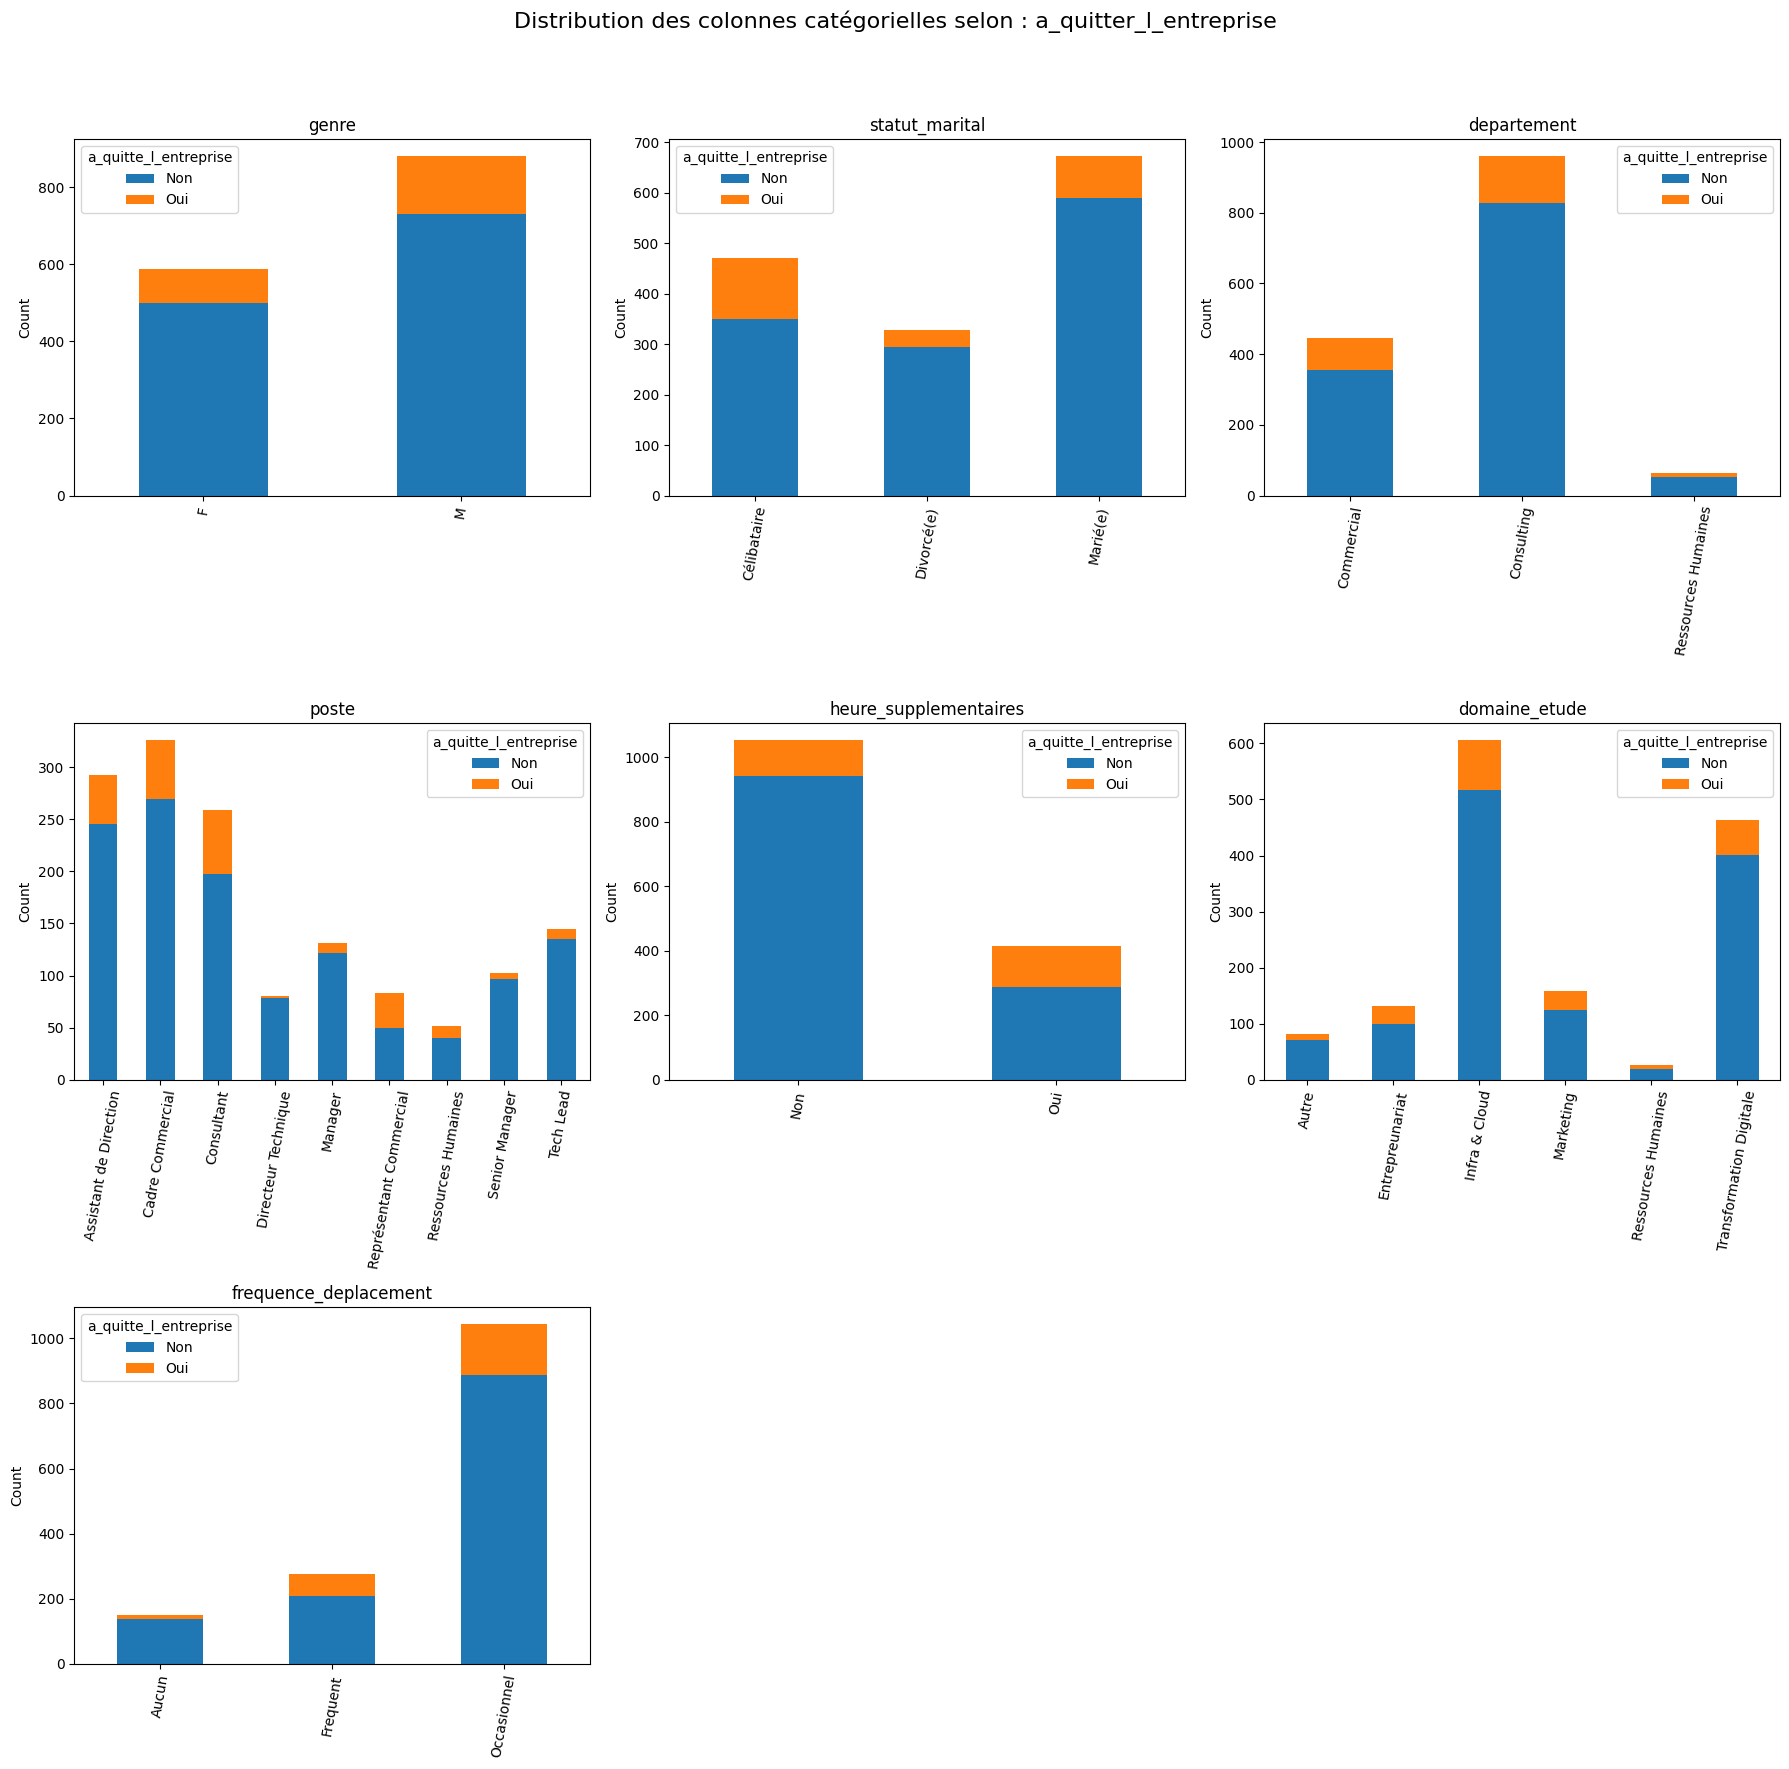

In [9]:
target = 'a_quitte_l_entreprise'

num_with_id = df.select_dtypes(include='number')
num = num_with_id.drop(columns=['id_employee', target], errors='ignore')

n_cols = 4
n_rows = int(np.ceil(len(num.columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num.columns):
    sns.histplot(
        data=df,
        x=col,
        hue=target,
        bins=30,
        stat='count',
        multiple='stack',
        ax=ax
    )
    # ax.set_title(col)

# Masquer les axes vides (comme pandas.hist)
for ax in axes[len(num.columns):]:
    ax.axis('off')

fig.suptitle("Distribution des colonnes numériques selon : a_quitter_l_entreprise", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Catégorielles
cat = df.select_dtypes(exclude='number').drop(columns=[target], errors='ignore')

n_cols = 3
n_rows = int(np.ceil(len(cat.columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 18)) # 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, cat.columns):

    # Top modalités pour la lisibilité
    top_cat = df[col].value_counts().head(10).index
    data_plot = df[df[col].isin(top_cat)]

    counts = (
        data_plot.groupby(col)[target]
        .value_counts()
        .unstack(fill_value=0)
    )

    counts.plot(
        kind='bar',
        stacked=True,
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=80)

# Masquer les axes vides
for ax in axes[len(cat.columns):]:
    ax.axis('off')

fig.suptitle(
    "Distribution des colonnes catégorielles selon : a_quitter_l_entreprise",
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [10]:
df["a_quitte_l_entreprise"].value_counts(normalize=True)

a_quitte_l_entreprise
Non    0.838776
Oui    0.161224
Name: proportion, dtype: float64

### 6) Transformation de la variable cible binaire en int : 0 / 1

In [11]:
df['a_quitte_l_entreprise'] = df['a_quitte_l_entreprise'].map({'Oui': 1, 'Non': 0})

### 7) Analyse des corrélations

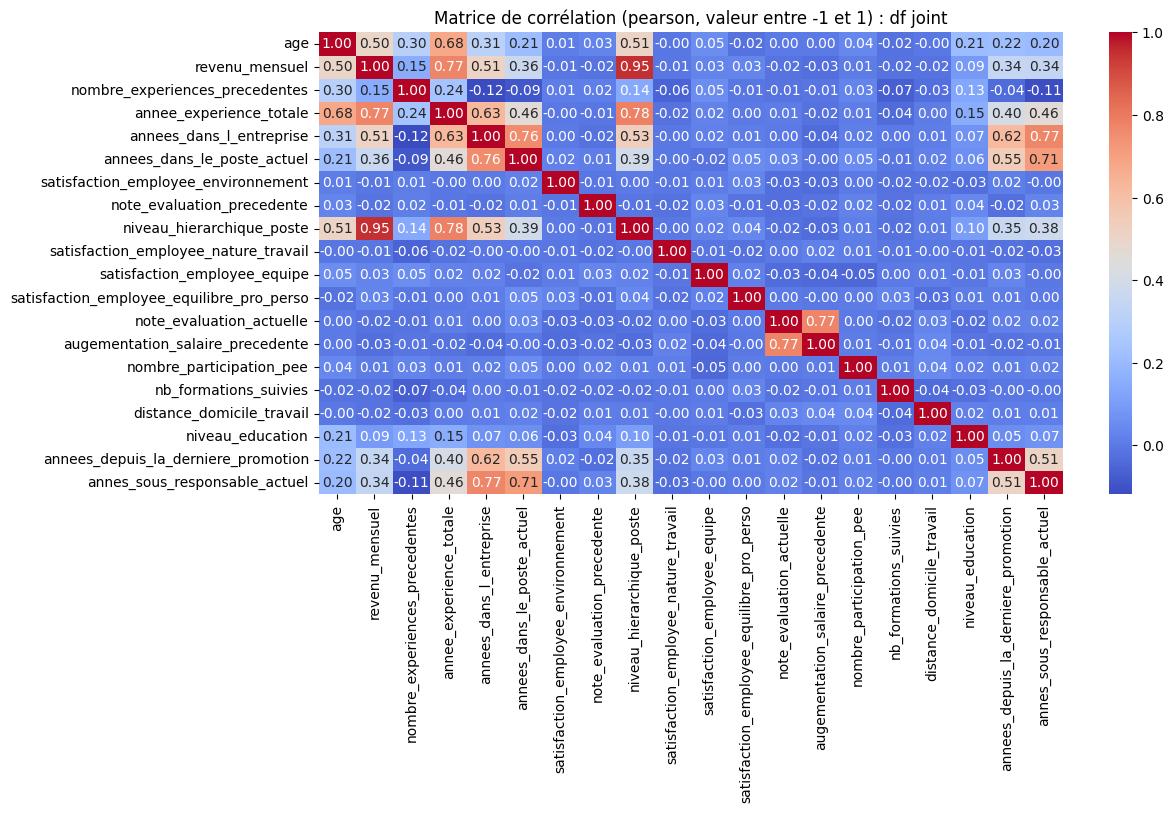

Paires fortement corrélée (|r| > 0.7)
revenu_mensuel               niveau_hierarchique_poste           0.950300
annee_experience_totale      niveau_hierarchique_poste           0.782208
note_evaluation_actuelle     augementation_salaire_precedente    0.773550
revenu_mensuel               annee_experience_totale             0.772893
annees_dans_l_entreprise     annes_sous_responsable_actuel       0.769212
                             annees_dans_le_poste_actuel         0.758754
annees_dans_le_poste_actuel  annes_sous_responsable_actuel       0.714365
dtype: float64


In [66]:
# Matrice de corrélation
plt.figure(figsize=(12,6))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title(f'Matrice de corrélation (pearson, valeur entre -1 et 1) : df joint')
# Interprétation rapide :
# |r| < 0.3 → faible, 0.3–0.7 → modéré, |r| > 0.7 → fort.
# r > 0 → variables croissent ensemble ; r < 0 → l’une croît quand l’autre décroît.
# À surveiller : paires très corrélées (|r| > 0.8) → risque de multicolinéarité (redondance), utile pour réduire la dimension (PCA) ou supprimer une variable dans un modèle.
# Rappel important : corrélation ≠ causalité — une forte corrélation n’implique pas une relation de cause à effet.
plt.show()

# Paires fortement corrélée
corr = num.corr().abs()
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
)
high_pairs = pairs[pairs > 0.7]

if not high_pairs.empty:
    print("="*60)
    print("Paires fortement corrélée (|r| > 0.7)")
    print("="*60)
    print(high_pairs)

    # for p in high_pairs.index:
    #     c1, c2 = p
    #     plt.figure(figsize=(6,6))
    #     sns.scatterplot(data=num, x=c1, y=c2)
    #     plt.title(f"Paire : {c1} vs {c2}")
    #     plt.show()

Multicolinéarité des variables : annee_experience_totale → niveau_hierarchique_poste → revenu_mensuel.

Pour éviter une instabilité des coefficients lors de l'entrainement d'un modèle linéaire, on choisit de garder celle qui sera la plus fortement corrélée à la variable cible.


In [67]:
# Corrélation des variables revenu_mensuel, annee_experience_totale, niveau_hierarchique_poste avec la target
print("Corrélation revenu_mensuel vs target :", df['revenu_mensuel'].corr(df['a_quitte_l_entreprise']))
print("Corrélation annee_experience_totale vs target :", df['annee_experience_totale'].corr(df['a_quitte_l_entreprise']))
print("Corrélation niveau_hierarchique_poste vs target :", df['niveau_hierarchique_poste'].corr(df['a_quitte_l_entreprise']))

Corrélation revenu_mensuel vs target : -0.15983958238498885
Corrélation annee_experience_totale vs target : -0.17106324613622667
Corrélation niveau_hierarchique_poste vs target : -0.16910475093102703


'annee_experience_totale' a la corrélation (en valeur absolue) la plus forte avec la target, donc on gardera uniquement celle-ci sur les 3.

## Séparation du dataset en X et y

In [12]:
X = df.drop(columns=["a_quitte_l_entreprise", 'id_employee'], errors='ignore') # on drop les id et la variable cible 
y = df['a_quitte_l_entreprise']

## Encodage des variables catégorielles 
One Hot Encoding pour les modèles linéaires et Label Encoding pour les autres modèles

In [69]:
df_cat = X.select_dtypes(exclude='number')
df_num = X.select_dtypes(include='number')

# One-Hot Encoding pour les colonnes catégorielles
ohe = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

df_cat_encoded = pd.DataFrame(
    ohe.fit_transform(df_cat),
    columns=ohe.get_feature_names_out(df_cat.columns),
    index=df_cat.index # pour garder les mêmes index que df_cat
)

X_ohe = pd.concat([df_num.drop(columns=['niveau_hierarchique_poste', 'revenu_mensuel'], errors='ignore'), df_cat_encoded], axis=1)

# Label Encoding pour les colonnes catégorielles
label_encoders = {}
label_mappings = {}

for col in df_cat.columns:
    le = LabelEncoder()
    df_cat[col] = le.fit_transform(df_cat[col])
    label_encoders[col] = le
    # Mapping catégorie -> code
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

for col in df_cat.select_dtypes(include='object').columns:
    df_cat[col] = df_cat[col].astype(int)
    
X_encoded = pd.concat([df_num, df_cat], axis=1)

print("Shape of categorical variables:")
print(df_cat.shape)
print("Shape of X before encoding:")
print(X.shape)
print("Shape of X after encoding categorical variables (one hot encoding):")
print(X_ohe.shape)
print("Shape of X after encoding categorical variables (label encoding):")
print(X_encoded.shape)

Shape of categorical variables:
(1470, 7)
Shape of X before encoding:
(1470, 27)
Shape of X after encoding categorical variables (one hot encoding):
(1470, 39)
Shape of X after encoding categorical variables (label encoding):
(1470, 27)


## Entrainement du modèle linéaire - Regression logistic

Les données sont divisées en train (80 %) et test (20 %) avec stratification afin de conserver la même proportion de classes dans le train et le test.

============= LogisticRegression with One-Hot Encoding =============

Best params: {'logreg__C': 1, 'logreg__solver': 'lbfgs'}
Best CV score: 0.559
CV results du best model (moyenne des scores):
f1         : 0.559 | écart-type : 0.042
roc_auc    : 0.840 | écart-type : 0.055
pr_auc     : 0.661 | écart-type : 0.072
precision  : 0.750 | écart-type : 0.074
recall     : 0.447 | écart-type : 0.037

===== Optimisation du seuil sur le jeu de TRAIN =====
Seuil optimal (F1) : 0.386

===== Résultats sur le jeu de TEST (seuil optimisé) =====
F1 Score: 0.519
ROC AUC Score: 0.823
PR AUC Score: 0.587
Accuracy: 0.867
Precision: 0.618
Recall: 0.447
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       247
           1       0.62      0.45      0.52        47

    accuracy                           0.87       294
   macro avg       0.76      0.70      0.72       294
weighted avg       0.85      0.87      0.86       294



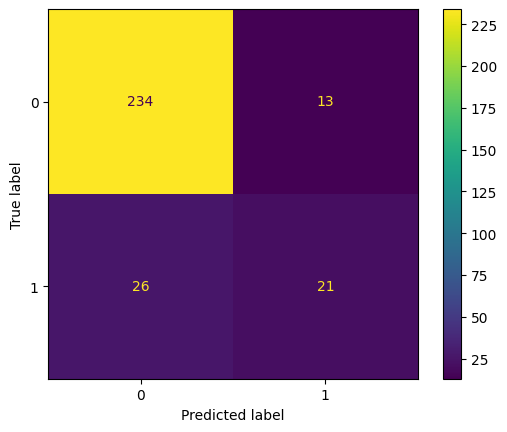

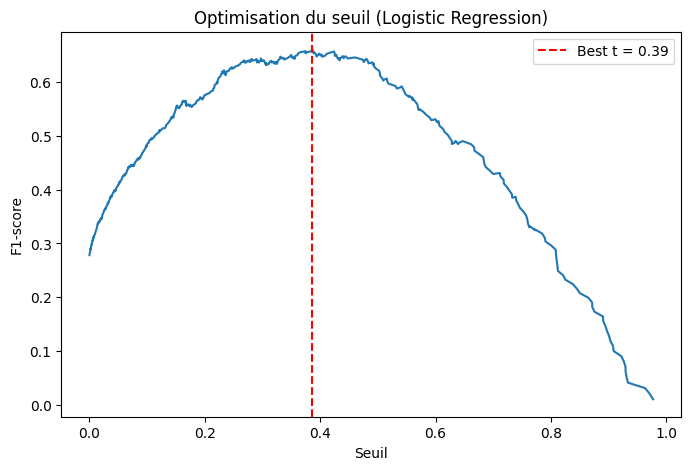

In [79]:
scoring = {
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc' : 'average_precision',
    'precision': 'precision',
    'recall': 'recall'
}

X_train, X_test, y_train, y_test = train_test_split(X_ohe, y, test_size=0.2, random_state=42, stratify=y)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=11000))
])

# GridSearch parameters
param_grid = {
    "logreg__C": [0.01, 0.1, 1, 10],
    "logreg__solver": ["lbfgs", "liblinear"]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring=scoring,
    refit="f1",
    n_jobs=-1
)

# Entraînement
grid.fit(X_train, y_train)

# Résultats

print("============= LogisticRegression with One-Hot Encoding =============")
print("\nBest params:", grid.best_params_)
print(f"Best CV score: {grid.best_score_:.3f}")

print("CV results du best model (moyenne des scores):")
best_idx = grid.best_index_

for m in scoring.keys():
    mean = grid.cv_results_[f"mean_test_{m}"][best_idx]
    std  = grid.cv_results_[f"std_test_{m}"][best_idx]
    print(f"{m:10s} : {mean:.3f} | écart-type : {std:.3f}")


best_model = grid.best_estimator_

# Probabilités sur le TRAIN
y_train_proba = best_model.predict_proba(X_train)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_proba)
# Calcul du F1 pour chaque seuil
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9) # 1e-9 pour eviter la division par 0 # on calcule f1_score pour chaque seuil

# Meilleur seuil
best_threshold = thresholds[f1_scores[:-1].argmax()] # seuil appris sur le train et appliqué sur le test

print("\n===== Optimisation du seuil sur le jeu de TRAIN =====")
print(f"Seuil optimal (F1) : {best_threshold:.3f}")

# Probabilités sur le TEST
y_proba = best_model.predict_proba(X_test)[:, 1]

# Prédictions avec seuil optimisé
y_pred_opt = (y_proba >= best_threshold).astype(int)

print("\n===== Résultats sur le jeu de TEST (seuil optimisé) =====")
print(f"F1 Score: {f1_score(y_test, y_pred_opt):.3f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.3f}")
print(f"PR AUC Score: {average_precision_score(y_test, y_proba):.3f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_opt):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_opt):.3f}")


print(classification_report(y_test, y_pred_opt))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm).plot()

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores[:-1])
plt.axvline(best_threshold, color='red', linestyle='--', label=f"Best t = {best_threshold:.2f}")
plt.xlabel("Seuil")
plt.ylabel("F1-score")
plt.title("Optimisation du seuil (Logistic Regression)")
plt.legend()
plt.show()


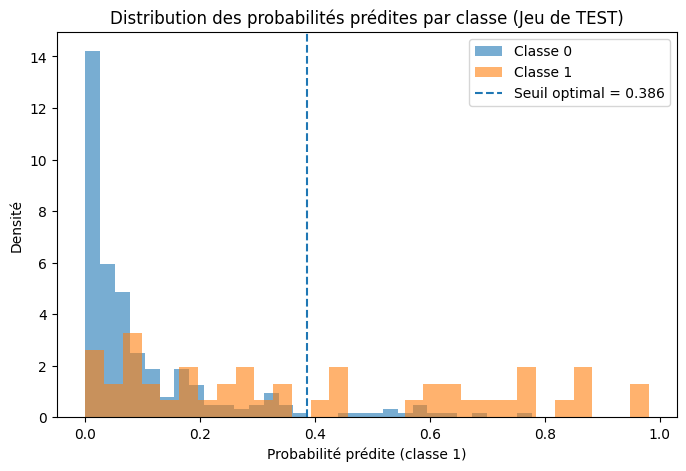

In [82]:
# Probabilités prédites sur le test
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# Séparation selon la vraie classe
proba_class_0 = y_proba_test[y_test == 0]
proba_class_1 = y_proba_test[y_test == 1]

plt.figure(figsize=(8,5))

plt.hist(proba_class_0, bins=30, alpha=0.6, density=True, label="Classe 0")
plt.hist(proba_class_1, bins=30, alpha=0.6, density=True, label="Classe 1")

# Ligne verticale du seuil optimal
plt.axvline(best_threshold, linestyle='--',
            label=f"Seuil optimal = {best_threshold:.3f}")

plt.xlabel("Probabilité prédite (classe 1)")
plt.ylabel("Densité")
plt.title("Distribution des probabilités prédites par classe (Jeu de TEST)")
plt.legend()

plt.show()

### Interprétation des résultats
Le modèle de régression logistique présente des performances stables entre validation croisée (F1 ≈ 0.55) et jeu de test (F1 ≈ 0.52), indiquant une bonne capacité de généralisation.

L’optimisation du seuil de décision (seuil à 0.39) permet d'obtenir un meilleur contrôle du compromis precision–recall en maximisant le f1 score, rendant le modèle plus adapté à un contexte de mise en prod.

* Precision = 0.618 et recall = 0.45 → quand le modèle prédit 1, il a raison 62 % du temps mais ne détecte que 45 % des vrais 1
* F1 = 0.52 → équilibre entre précision et rappel, mais reste relativement faible.
* ROC AUC = 0.82 → le modèle distingue assez bien les classes globalement, même si le F1 est faible.
* PR AUC = 0.59 → le modèle est moins performant pour la classe minoritaire (1).

**Conclusion :** On constate un déséquilibre de classes, le modèle favorise la classe majoritaire (0) et se voit donc peu sensible pour détecter les 1.

## Analyse des features

### Avec feature_importances

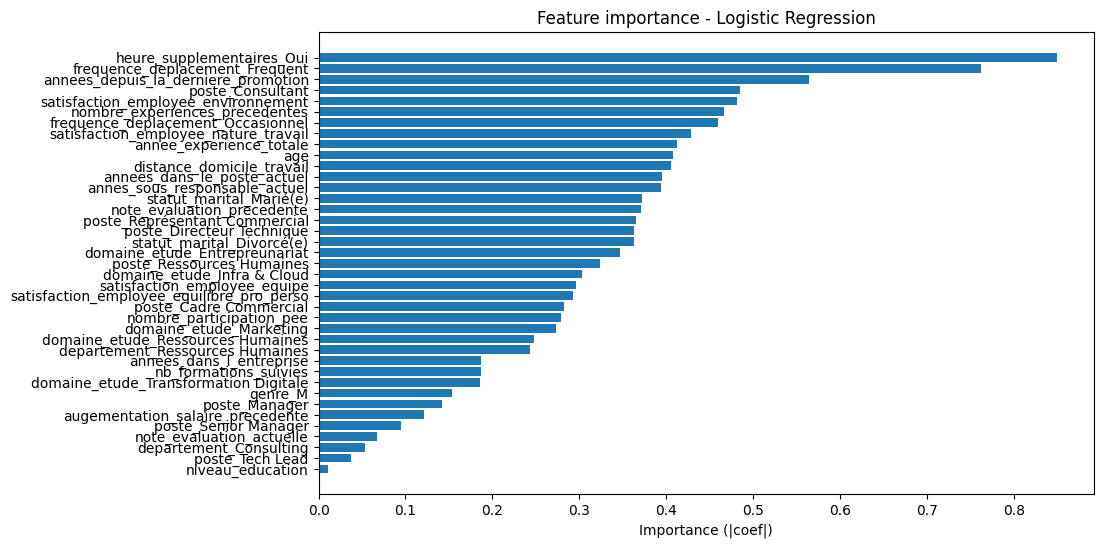

In [71]:
# Récupérer le modèle final LogisticRegression
logreg_model = grid.best_estimator_.named_steps["logreg"] # logreg le nom du model dans le pipeline

# Récupérer les coefficients
coefficients = logreg_model.coef_[0]  # vecteur des coefficients
features = X_train.columns            # noms des features

# Magnitude = importance (indépendamment du signe)
df_coef = pd.DataFrame({
    "feature": features,
    "coef": coefficients,
    "importance": abs(coefficients)
})

# Trier par importance décroissante
df_coef = df_coef.sort_values(by="importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(df_coef["feature"], df_coef["importance"])
plt.xlabel("Importance (|coef|)")
plt.title("Feature importance - Logistic Regression")
plt.gca().invert_yaxis()  # la plus importante en haut
plt.show()

Grace à l'analyse des features, on observe le TOP 3 des facteurs les plus déterminant au départ d'un collaborateur :
1) L'accomplissement d'heures supplémentaires
2) La réalisation de déplacement fréquent
3) Le nombre d'année depuis la dernière promotion

### Avec SHAP

**Rappel des notions SHAP**

Baseline = la moyenne de prédiction

Feature value = les valeurs de la colonne

SHAP value = la contribution d’une feature spécifique à la prédiction du modèle
* Positif → la feature pousse la prédiction vers 1
* Négatif → la feature pousse la prédiction vers 0

f(x) = la prédiction du modèle pour un individus

Signification des couleurs et barres :
* Rouge → feature qui pousse vers la classe positive (1)
* Bleu → feature qui pousse vers la classe négative (0)
* Longueur de la barre → magnitude de la contribution

In [53]:
explainer = shap.Explainer(best_model.named_steps["logreg"], X_train, feature_names=X_train.columns)
shap_values = explainer(X_test)

**Analyse globale des features**

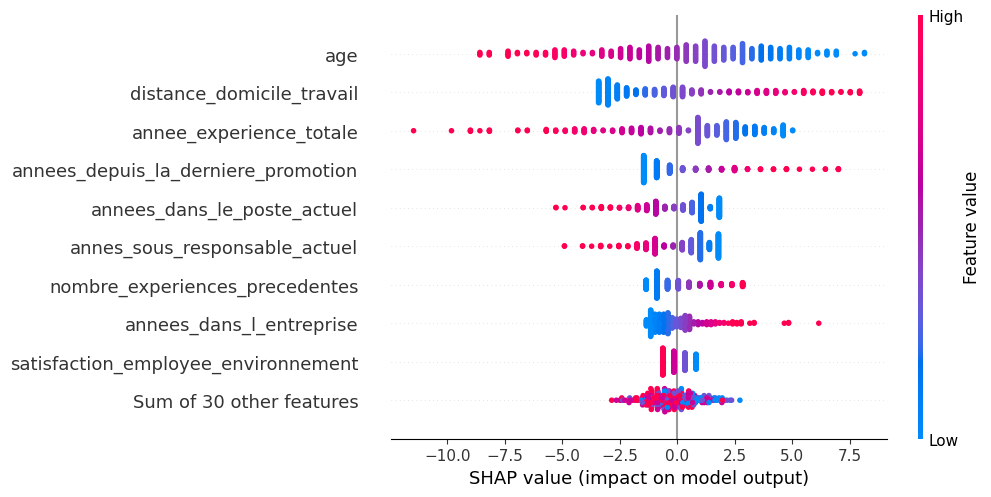

In [72]:
shap.plots.beeswarm(shap_values)

On observe que :
* plus le salarié est jeune,
* plus la distance entre le domicile du salarié et l'entreprise est grande
* plus le nombre d’années sans promotion augmente,
* plus le salarié a d'expérience,

ALORS le salarié risque fortement de quitter l'entreprise.

On va préférer nos interprétation avec SHAP plutôt que feature_importances, car SHAP prend en compte l’effet marginal de chaque feature et les interactions, donnant une mesure plus fidèle de l’influence sur la prédiction.

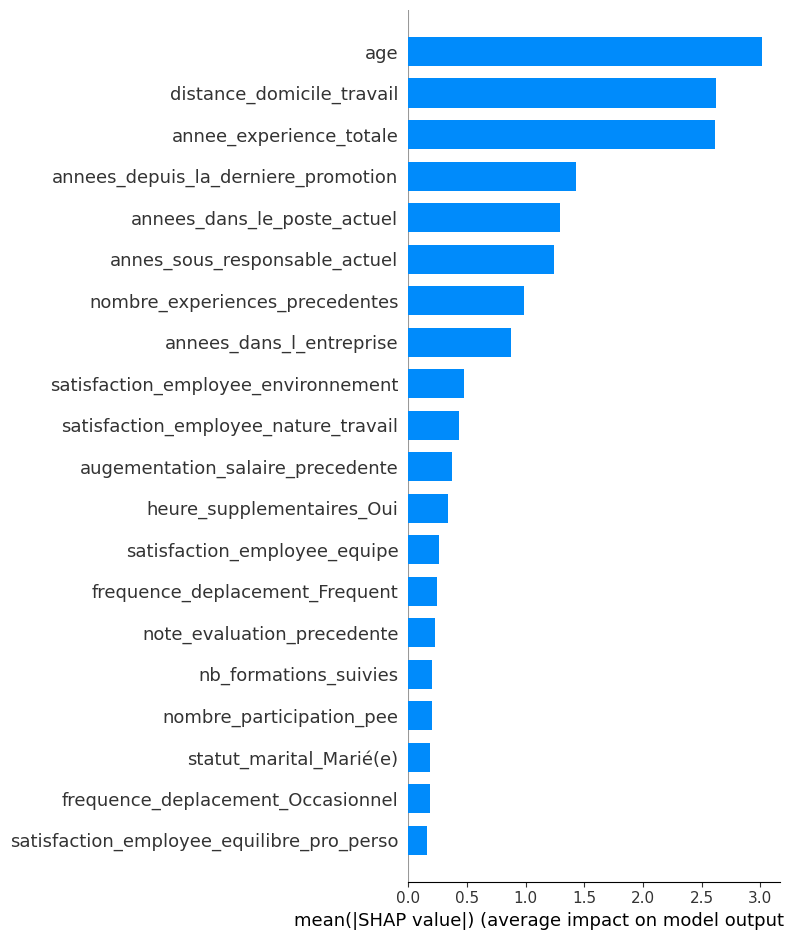

In [73]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

**Pour un individus**

In [74]:
shap.plots.force(shap_values[0])

f(x) = 14.33 < 0 donc le modèle prédit l'individus à la classe 0.

Les features en rouge tirent la prédiction vers la classe positive, on observe bien un décalage par rapport à la baseline. 

Celles qui jouent le plus grand role sont 'age' et 'annee_experience_totale'.

## Entrainement d'autres modèles : Dummy, RandomForest, XGBoost

Les données sont divisées en train (80 %) et test (20 %) avec stratification afin de conserver la même proportion de classes dans le train et le test. Le déséquilibre des classes est aussi pris en compte via des paramètres spécifiques aux modèles (class_weight et scale_pos_weight).

Trois modèles sont comparés (Dummy, Random Forest, XGBoost) à l’aide d’une GridSearch avec validation croisée stratifiée. Le modèle final est sélectionné selon le meilleur F1-score, métrique adaptée aux classes déséquilibrées.

Sur ce modèle final, une analyse d’importance des variables est réalisée en combinant l’importance native du modèle et les valeurs SHAP. Plusieurs ratios des "variables les plus importantes" sont testés. Ensuite, le seuil de classification est optimisé sur le jeu d’entraînement afin de maximiser le F1-score.

Enfin, le modèle est réentraîné sur ce sous-ensemble de features sélectionnées avec seuil optimisé. Ainsi on obtient la meilleure configuration pour maximiser les performances du modèle.

Proportion des classes / Déséquilibre dans y_train:
Classe 0 : 986 | Classe 1 : 190
scale_pos_weight (poid de la classe positive) = 5.19

===== GridSearchCV : Dummy =====

--- Dummy | Best CV Results ---
Best params : {'strategy': 'stratified'}
Best F1 CV  : 0.1644

Metrics CV (mean ± std) :
f1        : 0.1644 ± 0.0300
roc_auc   : 0.5054 ± 0.0172
pr_auc    : 0.1640 ± 0.0061
precision : 0.1714 ± 0.0313
recall    : 0.1579 ± 0.0288

===== GridSearchCV : RandomForest =====

--- RandomForest | Best CV Results ---
Best params : {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best F1 CV  : 0.4868

Metrics CV (mean ± std) :
f1        : 0.4868 ± 0.0577
roc_auc   : 0.7921 ± 0.0296
pr_auc    : 0.5472 ± 0.0632
precision : 0.5389 ± 0.0568
recall    : 0.4526 ± 0.0871

===== GridSearchCV : XGBoost =====

--- XGBoost | Best CV Results ---
Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best F1 CV  : 0.5594

Metrics CV (

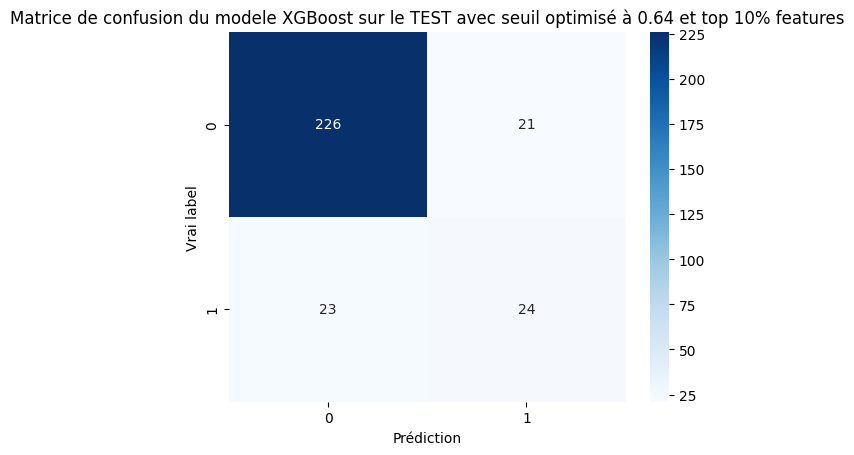

In [91]:

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Déséquilibre de classes
neg, pos = np.bincount(y_train)
poid_classe_pos = neg / pos if pos > 0 else 1 # Chaque 1 sera multiplié par ce poid dans l’algorithme pour compenser le déséquilibre. Sans ce poids le modèle pourrait prédire toujours 0

print("Proportion des classes / Déséquilibre dans y_train:")
print(f"Classe 0 : {neg} | Classe 1 : {pos}")
print(f"scale_pos_weight (poid de la classe positive) = {poid_classe_pos:.2f}")

##############################################################################

scoring = {
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc' : 'average_precision',
    'precision': 'precision',
    'recall': 'recall'
}

models = {
    "Dummy": {
        "model": DummyClassifier(random_state=42),
        "params": {
            "strategy": ["most_frequent", "stratified"]
        }
    },

    "RandomForest": {
        "model": RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            class_weight="balanced" # on donne plus de poid a la classe minoritaire (positive) pour un equilibre des classes
        ),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5]
        }
    },

    "XGBoost": {
        "model": XGBClassifier(
            random_state=42,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=poid_classe_pos # on compense le déséquilibre des classes avec ce poid
        ),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    }
}

##############################################################################

# GridSearchCV
grids = {}
cv_metrics_summary = {}
for name, mp in models.items():
    print(f"\n===== GridSearchCV : {name} =====")

    grid = GridSearchCV(
        estimator=mp["model"],
        param_grid=mp["params"],
        cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42), # on maintient la même répartition des classes dans chaque fold
        scoring=scoring,
        refit="f1", # on choisit le meilleur modèle selon le f1-score en cross validation
        n_jobs=-1,
        return_train_score=True
    )
    grid.fit(X_train, y_train)
    grids[name] = grid
    results = grid.cv_results_
    best_idx = grid.best_index_

    print(f"\n--- {name} | Best CV Results ---")
    print(f"Best params : {grid.best_params_}")
    print(f"Best F1 CV  : {grid.best_score_:.4f}")

    print("\nMetrics CV (mean ± std) :")
    for metric in scoring.keys():
        mean_val = results[f"mean_test_{metric}"][best_idx]
        std_val = results[f"std_test_{metric}"][best_idx]
        print(f"{metric:10s}: {mean_val:.4f} ± {std_val:.4f}")


# Sélection du meilleur modèle (CV ONLY)
best_model_name = max(grids, key=lambda name: grids[name].best_score_) # on garde le model qui a le meilleur f1-score en cross validation
final_model = grids[best_model_name].best_estimator_

print("\n=========================")
print(f"Meilleur modèle (CV) choisi : {best_model_name}")

##############################################################################

# Optimisation du seuil

# V1
# y_proba = final_model.predict_proba(X_train)[:, 1] # on recupère la probabilité de la classe 1 pour chaque ligne de X_train
# precisions, recalls, thresholds = precision_recall_curve(y_train, y_proba) # on calcule precision & recall pour tous les seuils candidats (toutes les probabilités uniques dans y_proba)

# # f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9) 
# f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9) # 1e-9 pour eviter la division par 0 # on calcule f1_score pour chaque seuil
# best_threshold = thresholds[np.argmax(f1_scores)] # on choisi le seuil qui maximise F1 sur l’ensemble d’entraînement
# print(f"Seuil optimal du modèle (maximise F1) : {best_threshold:.2f}")

# V2
# Correction du seuil car trop haut, mauvais résultats sur le test 
# Séparation interne train/validation pour seuil
# X_tr, X_val, y_tr, y_val = train_test_split(
#     X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
# )
# # Fit final model sur X_tr
# final_model.fit(X_tr, y_tr)
# # Optimisation du seuil sur validation
# y_val_proba = final_model.predict_proba(X_val)[:, 1]
# precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)
# f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
# best_threshold = thresholds[np.argmax(f1_scores)]
# print(f"Seuil optimal du modèle sur validation : {best_threshold:.2f}")

##############################################################################################

# Évaluation finale (TEST)
y_test_proba = final_model.predict_proba(X_test)[:, 1] # on garde que la proba de la classe 1 sur le jeu de test
y_test_pred = (y_test_proba >= best_threshold).astype(int) # on predit 1 si proba >= seuil_choisi, sinon 0

# if y_test_pred.sum() == 0:
#     print("Aucun positif prédit sur le test. Ajustement du seuil.")
#     best_threshold = 0.5  # fallback
#     y_test_pred = (y_test_proba >= best_threshold).astype(int)

print("\n===== Résultats sur le jeu de TEST =====")
print(f"F1-score : {f1_score(y_test, y_test_pred):.3f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_test_proba):.3f}")
print(f"PR AUC   : {average_precision_score(y_test, y_test_proba):.3f}")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_test_pred):.3f}")

print("\nClassification report :")
print(classification_report(y_test, y_test_pred))

##############################################################################
# on recupère l'importance des features du modèle final
if hasattr(final_model, "feature_importances_"):
    model_importance = final_model.feature_importances_
else:
    raise ValueError("final_model n'a pas feature_importances_")

# on initialise l'explainer SHAP pour le modèle final
explainer = shap.Explainer(final_model, X_train)
shap_values = explainer(X_train)
shap_importance = np.abs(shap_values.values).mean(axis=0)

# Normalisation pour comparer les importances sur la même échelle (0 à 1)
def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-9)

model_imp_norm = normalize(model_importance)
shap_imp_norm = normalize(shap_importance)

# Score combiné (moyenne pondérée)
combined_importance = 0.5 * model_imp_norm + 0.5 * shap_imp_norm

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "model_imp": model_imp_norm,
    "shap_imp": shap_imp_norm,
    "combined": combined_importance
}).sort_values("combined", ascending=False)

# Réentraîner selon le meilleur ratio de features
ratios = [0.1, 0.2, 0.3, 0.5, 1.0] # 10, 20, 30, 50 et 100% des features les plus importantes
results_top_features = []
for r in ratios:
    n_features = int(len(X_train.columns) * r)
    top_features_r = importance_df.head(n_features)["feature"]
    X_train_r = X_train[top_features_r]
    X_test_r = X_test[top_features_r]

    model_r = clone(final_model)
    model_r.fit(X_train_r, y_train)

    # Recalcul du seuil optimal sur le train réduit
    y_proba_train_r = model_r.predict_proba(X_train_r)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_train, y_proba_train_r)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
    best_threshold_r = thresholds[np.argmax(f1_scores)]

    # Prédiction sur le test avec le seuil recalculé
    y_test_proba_r = model_r.predict_proba(X_test_r)[:, 1]
    y_test_pred_r = (y_test_proba_r >= best_threshold_r).astype(int)

    # Metrics
    f1 = f1_score(y_test, y_test_pred_r)
    pr_auc = average_precision_score(y_test, y_test_proba_r)
    roc = roc_auc_score(y_test, y_test_proba_r)
    score_comb = f1 + pr_auc  # somme simple pour sélectionner le meilleur ratio

    results_top_features.append({
        "ratio": r,
        "n_features": n_features,
        "f1": f1,
        "pr_auc": pr_auc,
        "roc_auc": roc,
        "score_comb": score_comb,
        "threshold": best_threshold_r
    })

results_df = pd.DataFrame(results_top_features)

# Réentraîner sur le meilleur ratio (F1 max)
best_row = results_df.loc[results_df['f1'].idxmax()] # ou score_comb pour prendre en compte à la fois f1 et pr_auc
best_ratio = best_row['ratio']
best_threshold_r = best_row['threshold']
top_features_best = importance_df.head(int(len(X_train.columns) * best_ratio))["feature"]
print("\n================================")
print("----- Optimisation du modèle final : Sélection des features et seuil optimisé -----")
print(f"\nMeilleur ratio de features : {int(best_ratio*100)}%, soit {len(top_features_best)} / {len(X_train.columns)}")
print("Features sélectionnées :", top_features_best.tolist())
print(f"Seuil optimisé pour ce ratio : {best_threshold_r:.3f}")

X_train_best = X_train[top_features_best]
X_test_best = X_test[top_features_best]

final_model_best = clone(final_model)
final_model_best.fit(X_train_best, y_train)

y_test_proba_best = final_model_best.predict_proba(X_test_best)[:, 1]
y_test_pred_best = (y_test_proba_best >= best_threshold_r).astype(int)

print(f"\n===== Résultats sur le TEST après sélection du top {int(best_ratio*100)}% features =====")
print(f"F1-score : {f1_score(y_test, y_test_pred_best):.3f}")
print(f"ROC AUC : {roc_auc_score(y_test, y_test_proba_best):.3f}")
print(f"PR AUC : {average_precision_score(y_test, y_test_proba_best):.3f}")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred_best):.3f}")
print(f"Precision: {precision_score(y_test, y_test_pred_best):.3f}")
print(f"Recall   : {recall_score(y_test, y_test_pred_best):.3f}")

print("\nClassification report :")
print(classification_report(y_test, y_test_pred_best))


print("\n======== MATRICE DE CONFUSION ==========")
# cm = confusion_matrix(y_test, y_test_pred)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
# plt.xlabel("Prédiction")
# plt.ylabel("Vrai label")
# plt.title(f"Matrice de confusion du modele {best_model_name} sur le TEST")
# plt.show()

cm2 = confusion_matrix(y_test, y_test_pred_best)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Prédiction")
plt.ylabel("Vrai label")
plt.title(f"Matrice de confusion du modele {best_model_name} sur le TEST avec seuil optimisé à {best_threshold_r:.2f} et top {int(best_ratio*100)}% features")
plt.show()


REMARQUE : Le poids à 5.19 signifie que chaque erreur sur un “1” coûte environ 5 fois plus qu’une erreur sur un “0”

### Analyse des features avec SHAP (sur modele XGBOOST avant optimisation des features)

**Rappel sur les notions SHAP :**

Baseline = la moyenne de prédiction

Feature value = les valeurs de la colonne

SHAP value = la contribution d’une feature spécifique à la prédiction du modèle
* Positif → la feature pousse la prédiction vers 1
* Négatif → la feature pousse la prédiction vers 0

f(x) = la prédiction du modèle pour cet individus

Signification des couleurs et barres :
* Rouge → feature qui pousse vers la classe positive (1)
* Bleu → feature qui pousse vers la classe négative (0)
* Longueur de la barre → magnitude de la contribution

**Pour un individus**

In [92]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)
shap.force_plot(explainer.expected_value, shap_values[0, :], X_test.iloc[0, :])

f(x) = -0.42 < 0 donc cet individus est prédit à la classe 0.

Par rapport à la baseline, on observe que les features en rouge tirent un peu la prédiction vers la classe positive mais pas assez pour prédire 1.
La feature qui a pousse le plus la prédiction vers 1 est 'revenu_mensuel'.


In [131]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)
shap.force_plot(explainer.expected_value, shap_values[1, :], X_test.iloc[1, :])

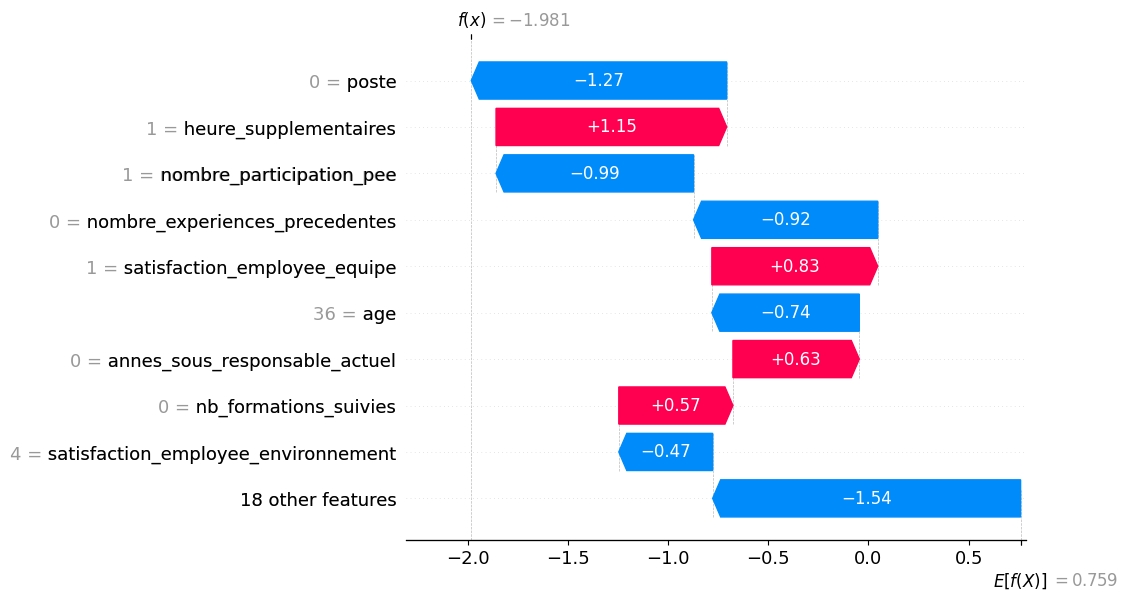

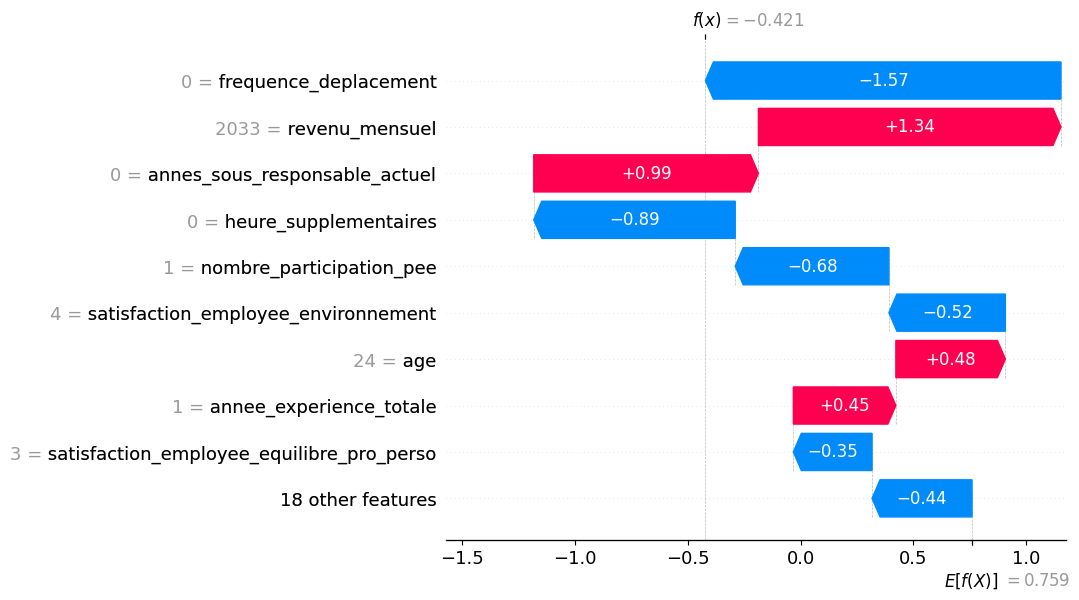

In [132]:
explainer = shap.Explainer(final_model)
shap_values = explainer(X_test)

# Trouver les positions dans X_test
idx_y1 = X_test[y_test == 1].index[0]  # index réel
idx_y0 = X_test[y_test == 0].index[0]

# Convertir index en position 0..n-1
pos_y1 = X_test.index.get_loc(idx_y1)
pos_y0 = X_test.index.get_loc(idx_y0)

# Waterfall pour individu y=1
shap.plots.waterfall(shap_values[pos_y1])
# Waterfall pour individu y=0
shap.plots.waterfall(shap_values[pos_y0])



**Analyse global de l'impact des features sur le modèle**

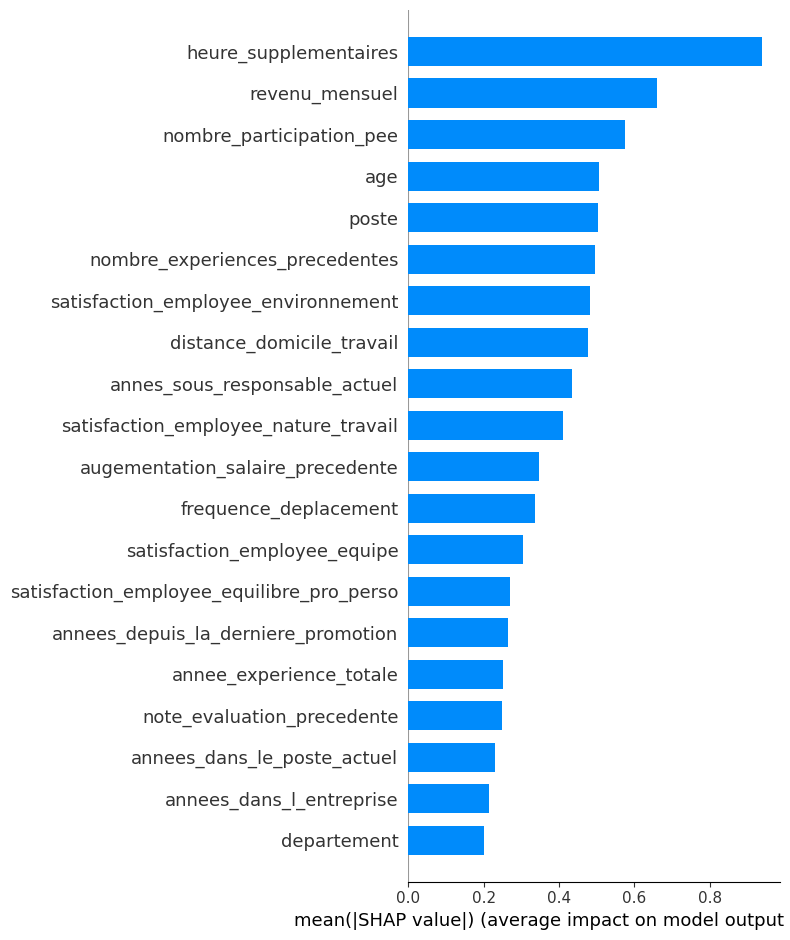

In [77]:
# Summary plot en barres (importance moyenne)
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.show()


Selon SHAP, pour le modèle XGBoost les 3 features les plus impactantes sur le modèle sont :
1) heure_supplementaires
2) revenu_mensuel
3) nombre_participation_pee

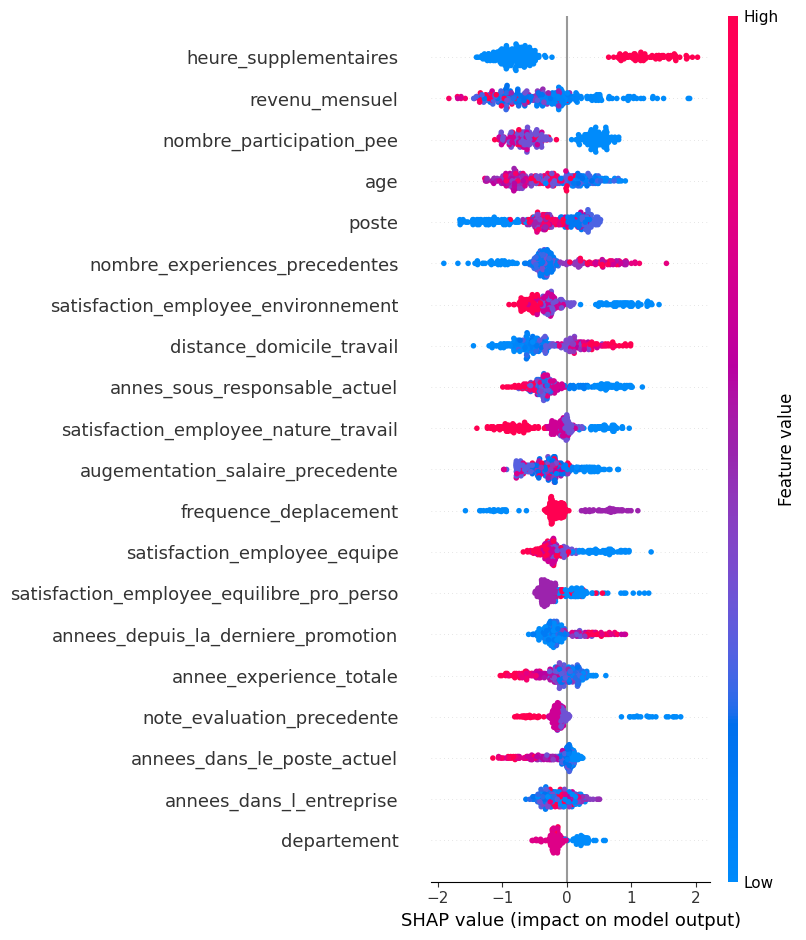

In [78]:
# Summary plot global (nuage)
plt.figure()
shap.summary_plot(shap_values, X_test)
plt.show()

On observe que :
* plus les heures supplémentaires sont élevés, 
* plus le salaire est faible et 
* moins le salarié participe 

ALORS le risque de démissionner est fort

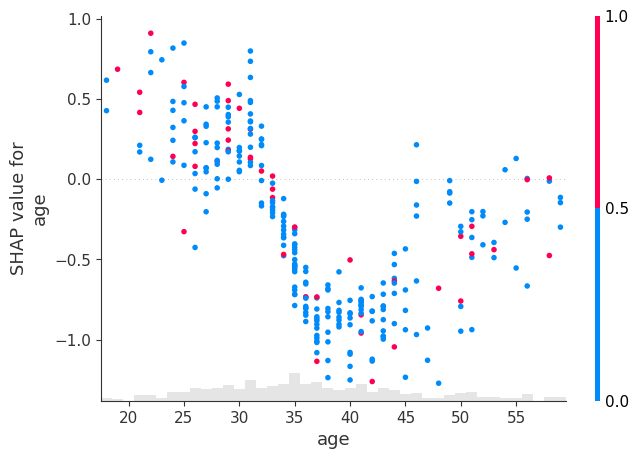

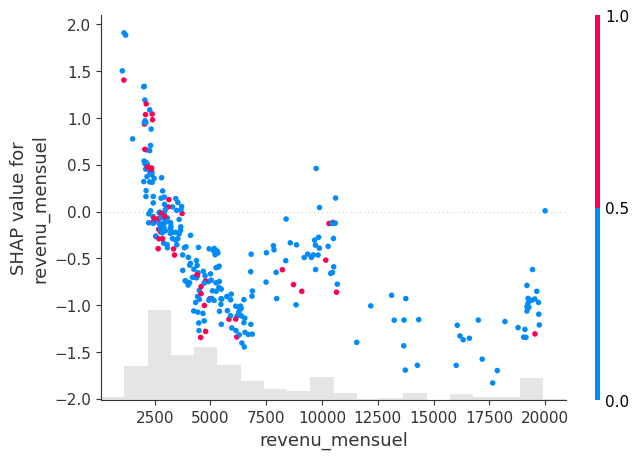

In [ ]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test)

shap.plots.scatter(shap_values[:, "age"], color=y_test.values)
shap.plots.scatter(shap_values[:, "revenu_mensuel"], color=y_test.values)